importing neccessary libraries

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

verifying the imports worked

In [15]:
import sys
import tensorflow as tf

print(sys.executable)
print(tf.__version__)

c:\Users\Sumanth\AppData\Local\Python\pythoncore-3.10-64\python.exe
2.15.0


dataset path


In [16]:
dataset_path = "C:\\Users\\Sumanth\\Documents\\projects\\data science project\\classification_dataset"

In [17]:
for cls in os.listdir(dataset_path):
    print(cls, len(os.listdir(os.path.join(dataset_path, cls))))

crab 378
dolphin 50
jellyfish 961
octopus 50
seahorse 50
seal 464
seaturtle 1003
shark 640
squid 483
starfish 688


building model

In [18]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    subset='validation'
)

Found 3817 images belonging to 10 classes.
Found 950 images belonging to 10 classes.


In [19]:
class_names = list(train_data.class_indices.keys())
print(class_names)

['crab', 'dolphin', 'jellyfish', 'octopus', 'seahorse', 'seal', 'seaturtle', 'shark', 'squid', 'starfish']


In [20]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [21]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),   
    layers.Dense(train_data.num_classes, activation='softmax')
])

compile model

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

train model

In [23]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
239/239 [==============================] - 69s 279ms/step - loss: 0.7315 - accuracy: 0.7750 - val_loss: 0.4355 - val_accuracy: 0.8663
Epoch 2/5
239/239 [==============================] - 66s 277ms/step - loss: 0.4463 - accuracy: 0.8538 - val_loss: 0.3883 - val_accuracy: 0.8674
Epoch 3/5
239/239 [==============================] - 66s 276ms/step - loss: 0.4104 - accuracy: 0.8646 - val_loss: 0.3795 - val_accuracy: 0.8842
Epoch 4/5
239/239 [==============================] - 66s 276ms/step - loss: 0.3495 - accuracy: 0.8847 - val_loss: 0.4030 - val_accuracy: 0.8747
Epoch 5/5
239/239 [==============================] - 67s 282ms/step - loss: 0.3125 - accuracy: 0.8944 - val_loss: 0.3804 - val_accuracy: 0.8811


plot the results

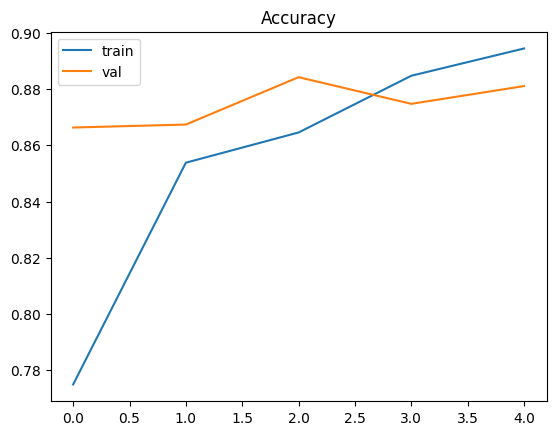

In [25]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

save model

In [28]:
model.save("C:\\Users\\Sumanth\\Documents\\projects\\Aquatic_classification_and_detection\\model\\aquatic_model_v2.keras")

In [37]:
import os

test_folder = r"C:\Users\Sumanth\Documents\projects\data science project\test_media"
for img_name in os.listdir(test_folder):
    img_path = os.path.join(test_folder, img_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = np.expand_dims(img, axis=0) / 255.0

    prediction = model.predict(img)

    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print(img_name, "→", predicted_class, f"({confidence:.2f})")

1/1 [==============================] - 0s 32ms/step
crab_1.jpg → squid (0.59)
1/1 [==============================] - 0s 32ms/step
crab_2.jpg → crab (1.00)
1/1 [==============================] - 0s 34ms/step
shark.jpg → shark (1.00)
1/1 [==============================] - 0s 32ms/step
starfish.jpg → starfish (1.00)
